In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,MaxPooling2D,Conv2D
from tensorflow.keras.applications import MobileNetV2 # Added import for MobileNetV2

In [ ]:
train_ds=keras.utils.image_dataset_from_directory(
    directory="/kaggle/input/dogsvscats/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(224,224) # Changed image size for MobileNetV2
)
validation_ds=keras.utils.image_dataset_from_directory(
    directory="/kaggle/input/dogsvscats/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(224,224)) # Changed image size for MobileNetV2

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [ ]:
def process(image,label):
  image=tf.cast(image/255.0,tf.float32)
  return image,label

train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

In [ ]:
model=Sequential()

# Data Augmentation Layers (kept)
model.add(keras.layers.RandomFlip("horizontal")) # Removed input_shape as it's handled by base_model later
model.add(keras.layers.RandomRotation(0.1))

# Load pre-trained MobileNetV2 base model
base_model = MobileNetV2(input_shape=(224, 224, 3),
                                include_top=False,
                                weights='imagenet')

# Freeze the base model for the first stage of training
base_model.trainable = False # Set to False for initial training of the head

# Add the base model to our sequential model
model.add(base_model)

# Add new classification layers on top
model.add(keras.layers.GlobalAveragePooling2D())
model.add(Dense(128,activation="relu"))
model.add(keras.layers.Dropout(0.5)) # Added Dropout
model.add(Dense(64,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), # Moderate learning rate for training the head
              metrics=["accuracy"])

In [ ]:
history=model.fit(train_ds,validation_data=validation_ds,epochs=10)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 100s 143ms/step - accuracy: 0.9596 - loss: 0.1074 - val_accuracy: 0.9812 - val_loss: 0.0498
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.9681 - loss: 0.0834 - val_accuracy: 0.9786 - val_loss: 0.0556
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9726 - loss: 0.0716 - val_accuracy: 0.9804 - val_loss: 0.0497
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.9735 - loss: 0.0691 - val_accuracy: 0.9824 - val_loss: 0.0449
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - accuracy: 0.9733 - loss: 0.0684 - val_accuracy: 0.9826 - val_loss: 0.0463
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9747 - loss: 0.0655 - val_accuracy: 0.9806 - val_loss: 0.0454
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 73ms/step - accuracy: 0.9761 - loss: 0.0598 - val_accuracy: 0.9830 - val_loss: 0.0506
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.9762 - loss: 0.0594 

In [ ]:
# Stage 2: Fine-tune the entire model with a very low learning rate

# Unfreeze the base model
base_model.trainable = True

# Recompile the model with a very low learning rate
model.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Very low learning rate for fine-tuning
              metrics=["accuracy"])

print("Starting fine-tuning of the entire model...")
# Continue training for more epochs
# Calculate the total number of epochs: previous_epochs + additional_epochs
initial_fine_tune_epoch = len(history.history['loss'])
total_fine_tune_epochs = initial_fine_tune_epoch + 10 # Train for 10 additional epochs

history_fine_tune = model.fit(train_ds, validation_data=validation_ds, epochs=total_fine_tune_epochs, initial_epoch=initial_fine_tune_epoch)

# Combine histories for plotting
history.history['loss'].extend(history_fine_tune.history['loss'])
history.history['val_loss'].extend(history_fine_tune.history['val_loss'])
history.history['accuracy'].extend(history_fine_tune.history['accuracy'])
history.history['val_accuracy'].extend(history_fine_tune.history['val_accuracy'])

Starting fine-tuning of the entire model...
Epoch 11/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 206s 284ms/step - accuracy: 0.9437 - loss: 0.1431 - val_accuracy: 0.9796 - val_loss: 0.0571
Epoch 12/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 176s 281ms/step - accuracy: 0.9732 - loss: 0.0732 - val_accuracy: 0.9856 - val_loss: 0.0407
Epoch 13/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 177s 283ms/step - accuracy: 0.9762 - loss: 0.0600 - val_accuracy: 0.9866 - val_loss: 0.0389
Epoch 14/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 176s 282ms/step - accuracy: 0.9812 - loss: 0.0511 - val_accuracy: 0.9872 - val_loss: 0.0376
Epoch 15/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 176s 282ms/step - accuracy: 0.9830 - loss: 0.0442 - val_accuracy: 0.9862 - val_loss: 0.0366
Epoch 16/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 176s 282ms/step - accuracy: 0.9855 - loss: 0.0384 - val_accuracy: 0.9856 - val_loss: 0.0375
Epoch 17/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 176s 282ms/step - accuracy: 0.9858 - loss: 0.0380 - val_accuracy: 0.9858 - val_loss: 0.0380
Epoch 18/20
625/625 ━━━━━

In [ ]:
y_pred=model.predict(validation_ds)

157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step


In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

# Extract true labels from validation_ds
y_true = []
for images, labels in validation_ds:
    y_true.append(labels.numpy())
y_true = np.concatenate(y_true)

# Convert y_pred probabilities to binary predictions (0 or 1)
y_pred_binary = np.where(y_pred > 0.5, 1, 0).flatten()

# Calculate accuracy
accuracy = accuracy_score(y_true, y_pred_binary)
print(f"Validation Accuracy: {accuracy:.4f}")

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
test_img=cv2.imread("/content/dog.webp")

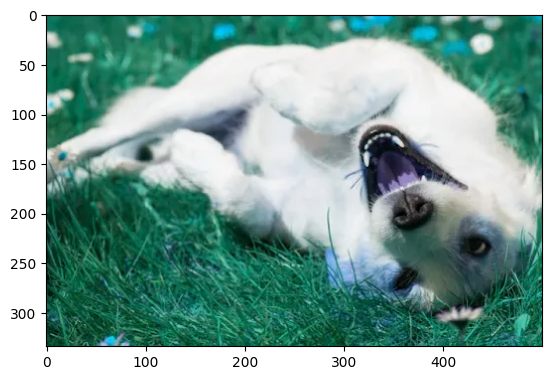

In [ ]:
plt.imshow(test_img)

In [ ]:
test_image=cv2.resize(test_img,(224,224))

In [ ]:
test_input=test_image.reshape((1,224,224,3))

In [ ]:
y_prob=model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
y_pred=np.where(y_prob>0.5,1,0)

In [ ]:
y_pred

array([[0]])